# Fedbiomed Example for Using Logistic Regression on Flamby Heart Disease Dataset

This notebook serves to show an example for predicting whether a patient has a heart disease using Flamby Dataset. The Flamby dataset consists of 4 samples, belonging to Cleveland, Hungarian, Switzerland and VA. In our example, we are going to use Cleveland and Hungarian for training, and VA for validation. We are going to compare the federated model with the centralized model and show their training performances and accuracies on an unseen validation dataset.

### Adding some imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split

### Script for Creating CSVs that are preprocessed and globally normalized.

In [183]:
in_paths = [
    "./data/cleveland.csv",
    "./data/hungarian.csv",
    "./data/va.csv",
]

out_before_norm_paths = [
    "./data/cleveland_clean_onehot_binary_BEFORE_norm.csv",
    "./data/hungarian_clean_onehot_binary_BEFORE_norm.csv",
    "./data/va_clean_onehot_binary_BEFORE_norm.csv",
]

for in_path, out_before_norm in zip(in_paths, out_before_norm_paths):
    # load + clean
    df = pd.read_csv(in_path, header=None)
    df = df.replace("?", np.nan).drop(df.columns[[10, 11, 12]], axis=1).dropna(axis=0)
    df = df.apply(pd.to_numeric)

    label_col = df.columns[-1]

    # one-hot encode categorical columns 2 (cp) and 6 (restecg)
    df = pd.get_dummies(df, columns=df.columns[[2, 6]], drop_first=True)

    # convert dummy bool columns True/False -> 0/1
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int64)

    # binarize label 0 vs >0 -> 0/1
    df[label_col] = (df[label_col] > 0).astype(np.int64)

    # ensure label is the LAST column
    feature_cols = [c for c in df.columns if c != label_col]
    df = df[feature_cols + [label_col]]

    # save BEFORE normalization
    df.to_csv(out_before_norm, header=False, index=False)

    print(f"Saved before normalization: {out_before_norm}")
    print("Dummy bool cols converted:", list(bool_cols))
    print("Shape:", df.shape)
    print("-" * 60)

Saved:
 - Before normalization: /mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_BEFORE_norm.csv
 - After normalization : /mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_AFTER_norm.csv
Dummy bool cols converted: ['4_2', '4_3', '4_4', '1.1_1', '1.1_2']


In [29]:
# Input / output paths (match by index)
in_paths = [
    "/mnt/c/Users/adincer/Desktop/fedbiomed/data/cleveland_clean_onehot_binary_BEFORE_norm.csv",
    "/mnt/c/Users/adincer/Desktop/fedbiomed/data/hungarian_clean_onehot_binary_BEFORE_norm.csv",
    "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_BEFORE_norm.csv",
]

out_paths = [
    "/mnt/c/Users/adincer/Desktop/fedbiomed/data/cleveland_globally_normalized.csv",
    "/mnt/c/Users/adincer/Desktop/fedbiomed/data/hungarian_globally_normalized.csv",
    "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_globally_normalized.csv",
]

# ---- Load all ----
dfs = [pd.read_csv(p, header=None, names=list(range(14))) for p in in_paths]

label_col = dfs[0].columns[-1]
feature_cols = [c for c in dfs[0].columns if c != label_col]

# ---- Compute global mu/sigma from the first two (centers) ----
combined = pd.concat(dfs[:2], axis=0)
mu = combined[feature_cols].mean()
sigma = combined[feature_cols].std(ddof=0).replace(0, 1)

# ---- Normalize each dataframe using global stats + save ----
for df, out_path in zip(dfs, out_paths):
    df_norm = df.copy()
    df_norm[feature_cols] = (df_norm[feature_cols] - mu) / sigma
    df_norm.to_csv(out_path, header=False, index=False)
    print("Saved after GLOBAL normalization:", out_path)

Saved after GLOBAL normalization: /mnt/c/Users/adincer/Desktop/fedbiomed/data/cleveland_globally_normalized.csv
Saved after GLOBAL normalization: /mnt/c/Users/adincer/Desktop/fedbiomed/data/hungarian_globally_normalized.csv
Saved after GLOBAL normalization: /mnt/c/Users/adincer/Desktop/fedbiomed/data/va_globally_normalized.csv


Helper function to sanity check whether there is a class imbalance or not.

In our example, we can see there is some imbalance in the VA dataset.

In [32]:
def check_class_imbalance(y, *, name="y"):
    y = np.asarray(y)
    vals, counts = np.unique(y, return_counts=True)
    total = counts.sum()

    report = pd.DataFrame({
        "class": vals,
        "count": counts,
        "pct": (counts / total * 100).round(2),
    }).sort_values("count", ascending=False)

    print(f"\nClass distribution for {name} (n={total}):")
    print(report.to_string(index=False))

    maj = counts.max()
    min_ = counts.min()
    print(f"\nMajority: {maj} ({maj/total:.2%})")
    print(f"Minority: {min_} ({min_/total:.2%})")
    print(f"Imbalance ratio (maj/min): {maj / max(min_, 1):.2f}x")

    return report

report = check_class_imbalance(pd.read_csv("./data/va_globally_normalized.csv", header=None).iloc[:, 13].to_numpy(), name="target")
print(report.shape)


Class distribution for target (n=129):
 class  count   pct
     1    100 77.52
     0     29 22.48

Majority: 100 (77.52%)
Minority: 29 (22.48%)
Imbalance ratio (maj/min): 3.45x
(2, 3)


### Defining the Training Plan

Pay attention that we are using hardcoded column indexes, as we don't have column names in the Flamby dataset.

We are using Balanced Accuracy for measuring the performance.

In [33]:
from fedbiomed.common.training_plans import FedSGDClassifier
from fedbiomed.common.dataset import TabularDataset
from fedbiomed.common.datamanager import DataManager

class SGDRegressorTrainingPlan(FedSGDClassifier):
    def init_dependencies(self):
        """Define additional dependencies."""
        return [
                "from fedbiomed.common.dataset import TabularDataset",
                "from sklearn.metrics import balanced_accuracy_score",
                "import numpy as np",
        ]

    def training_data(self):
        dataset = TabularDataset(input_columns=list(range(0,13)), target_columns=13)
        return DataManager(dataset=dataset)

    def testing_step(self, data, target):
        preds = self.model().predict(data)
        balanced_accuracy = balanced_accuracy_score(y_pred=preds, y_true=target)
        print("Pred: ", preds)
        print("Target: ", target)
        return balanced_accuracy

### Defining the Model and Training Arguments

In [56]:
model_args = {
    'n_features':13,
    'n_classes':2,
    'loss': 'log_loss',
    'learning_rate': "constant", 
    'eta0': 0.01,
    # 'alpha': 1e-4,
    # 'penalty': "l2",
    # 'random_state':RANDOM_SEED,
}

training_args = {
    # 'shuffle': True,
    'loader_args': { 'batch_size': 16, },
    'epochs': 2,
    'dry_run': False,
    'test_ratio' : 0.2,
    'test_batch_size': 16,
    'test_on_global_updates': True,
    'test_on_local_updates': True,
}

### Defining and Launching the Experiment

In [57]:
from fedbiomed.researcher.federated_workflows import Experiment
from fedbiomed.researcher.aggregators.fedavg import FedAverage

tags = ['global']
num_rounds = 50

exp = Experiment(tags=tags,
                 model_args=model_args,
                 training_plan_class=SGDRegressorTrainingPlan,
                 training_args=training_args,
                 round_limit=num_rounds,
                 aggregator=FedAverage(),
                )

2026-02-24 10:09:05,509 fedbiomed INFO - Updating training data. This action will update FederatedDataset, and the nodes that will participate to the experiment.

2026-02-24 10:09:05,533 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

2026-02-24 10:09:05,535 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

2026-02-24 10:09:05,538 fedbiomed INFO - Node selected for training -> Default Node Alias
Node ID is -> NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2

2026-02-24 10:09:05,539 fedbiomed INFO - Node selected for training -> Default Node Alias
Node ID is -> NODE_89269fb8-e88f-447b-bf40-6cff09f06a75

2026-02-24 10:09:05,563 fedbiomed DEBUG - Model file has been saved: /mnt/c/Users/adincer/Desktop/fedbiomed/fbm-researcher/var/experiments/Experiment_1001/model_9d47e89e-e2ff-42b9-afae-294e05cf5696.py

2026-02-24 10:09:05,606 fedbiomed WARNING - Option share_persistent_buffers is not supported in SKLearnTrainingPlan, it will be ignored.

2026-02-24 10:09:05,607 fedbiomed DEBUG - Using native Sklearn Optimizer

In [58]:
exp.run()

2026-02-24 10:09:07,863 fedbiomed INFO - Sampled nodes in round 0 ['NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2', 'NODE_89269fb8-e88f-447b-bf40-6cff09f06a75']

2026-02-24 10:09:07,878 fedbiomed INFO - Sending request 
					 To: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Request: : TRAIN
 -----------------------------------------------------------------

2026-02-24 10:09:07,880 fedbiomed INFO - Sending request 
					 To: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Request: : TRAIN
 -----------------------------------------------------------------

2026-02-24 10:09:07,896 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

2026-02-24 10:09:07,900 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

...

2026-02-24 10:10:50,746 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 1/4 (25%) | Samples: 16/52
 					 Custom: 0.873016 
					 ---------

2026-02-24 10:10:50,749 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 1/4 (25%) | Samples: 16/60
 					 Custom: 0.625000 
					 ---------

2026-02-24 10:10:50,861 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 4/4 (100%) | Samples: 52/52
 					 Custom: 0.833333 
					 ---------

2026-02-24 10:10:50,882 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 4/4 (100%) | Samples: 60/60
 					 Custom: 0.685714 
					 ---------

50

### Plotting the Losses and the Accuracies

In [112]:
nodes = exp.monitor()._metric_store.keys()
train_losses = {}
for node in nodes:
  train_losses[node] = list()
  for round in exp.monitor()._metric_store[node]['training']['Loss log_loss'].keys():
    round_loss = exp.monitor()._metric_store[node]['training']['Loss log_loss'][round]['values']
    train_losses[node].append(np.mean(round_loss))

balanced_accuracies = {}
for node in nodes:
    balanced_accuracies[node] = list()
    for round in exp.monitor()._metric_store[node]['testing_global_updates']['Custom'].keys():
      round_accs = exp.monitor()._metric_store[node]['testing_global_updates']['Custom'][round]['values']
      balanced_accuracies[node].append(np.mean(round_accs))

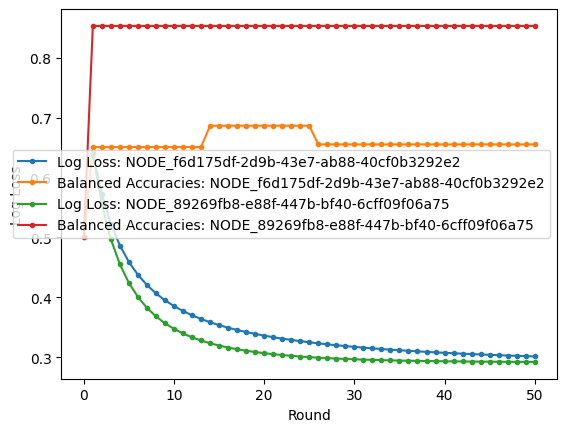

In [60]:
for node in nodes:
  plt.plot(range(1,exp.round_limit()+1), train_losses[node], '.-', label=f'Log Loss: {node}')
  plt.plot(range(exp.round_limit()+1), balanced_accuracies[node], '.-', label=f'Balanced Accuracies: {node}')
_ = plt.xlabel('Round')
_ = plt.ylabel('Log Loss')
plt.legend()

### Evaluating the performance of the model using the validation dataset

We again use the Balanced Accuracy metric and plot a Confusion Matrix to see our result.

In [61]:
federated_model = exp.training_plan().model()

In [62]:
path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_globally_normalized.csv"

df = pd.read_csv(path, header=None)

y_true = df.iloc[:, -1].to_numpy().astype(int)
X = df.drop(df.columns[-1], axis=1).to_numpy().astype(np.float32)

# Predict
y_pred = federated_model.predict(X)

bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)
print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))

Balanced accuracy: 0.6218965517241379

Confusion matrix:
 [[12 17]
 [17 83]]

Classification report:
               precision    recall  f1-score   support

           0     0.4138    0.4138    0.4138        29
           1     0.8300    0.8300    0.8300       100

    accuracy                         0.7364       129
   macro avg     0.6219    0.6219    0.6219       129
weighted avg     0.7364    0.7364    0.7364       129



## Centralized Model

We will continue with defining a centralized model with same parameters, and try to compare it with the federated model.

### We define the same parameters

We accumulate the data in a central dataframe (node). We are going to use the centralized data for training.

In [109]:
df_centralized = pd.concat((df_c1,df_c2), axis=0)

X = df_centralized.iloc[:, :-1].to_numpy(dtype=np.float64)
y = df_centralized.iloc[:, -1].to_numpy(dtype=np.int64)

# Train/test split (test_ratio = 0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

centralized_model = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1,           # with partial_fit / epoch loop; or set higher if using fit()
    tol=None,             # disable early stopping so epochs are controlled externally
    average=True,
    shuffle=False,
)

### We launch a centralized training

We use the same parameters, and we plot the result for log losses and accuracy.

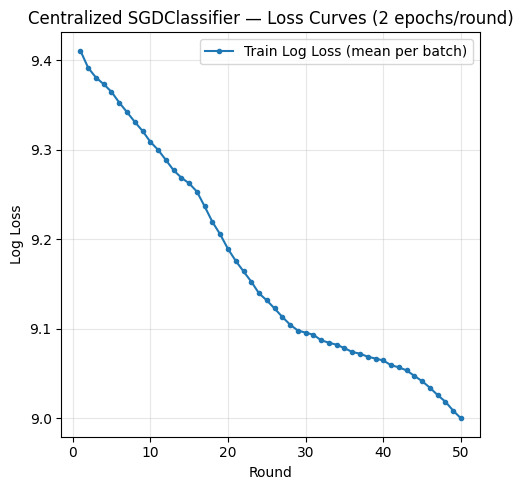

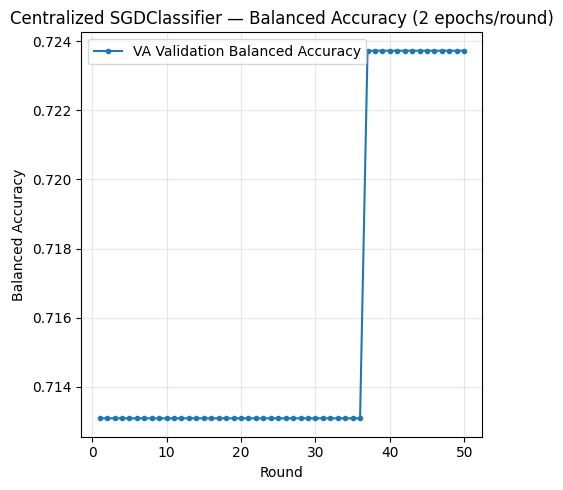

2026-02-24 11:51:28,259 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

In [113]:
# -----------------------------
# TRAINING SETTINGS
# -----------------------------
rounds = 50
epochs_per_round = 2
batch_size = 16
classes = np.array([0, 1], dtype=np.int64)

def iterate_minibatches_in_order(X, y, batch_size):
    n = len(X)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield X[start:end], y[start:end]

def mean_batch_log_loss(centralized_model, X, y, batch_size, classes):
    # Average of per-batch log_loss values (closer to "training batch loss" logging)
    losses = []
    for xb, yb in iterate_minibatches_in_order(X, y, batch_size):
        proba = centralized_model.predict_proba(xb)
        losses.append(log_loss(yb, proba, labels=classes))
    return float(np.mean(losses)) if losses else np.nan

train_log_losses = []
test_bal_accs = []

first_fit_done = False

# -----------------------------
# TRAIN LOOP: rounds x epochs_per_round
# -----------------------------
for r in range(1, rounds + 1):
    for e in range(epochs_per_round):
        for xb, yb in iterate_minibatches_in_order(X_train, y_train, batch_size):
            if not first_fit_done:
                centralized_model.partial_fit(xb, yb, classes=classes)
                first_fit_done = True
            else:
                centralized_model.partial_fit(xb, yb)

    # Mean of per-batch log losses (often closer to what you saw)
    ll_mean_batch = mean_batch_log_loss(centralized_model, X_train, y_train, batch_size, classes)
    train_log_losses.append(ll_mean_batch)
            
    # Balanced Accuracies
    y_test_pred = centralized_model.predict(X_test)
    test_bal_accs.append(balanced_accuracy_score(y_test, y_test_pred))

# -----------------------------
# PLOT
# -----------------------------
x = np.arange(1, rounds + 1)

# Plot 1: losses
plt.figure(figsize=(5, 5))
plt.plot(x, train_log_losses, ".-", label="Train Log Loss (mean per batch)")
plt.xlabel("Round")
plt.ylabel("Log Loss")
plt.title(f"Centralized SGDClassifier — Loss Curves ({epochs_per_round} epochs/round)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: balanced accuracies
plt.figure(figsize=(5, 5))
plt.plot(x, test_bal_accs, ".-", label="VA Validation Balanced Accuracy")
plt.xlabel("Round")
plt.ylabel("Balanced Accuracy")
plt.title(f"Centralized SGDClassifier — Balanced Accuracy ({epochs_per_round} epochs/round)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### We plot the confusion matrix and see we have obtained a similar resilt with the centralized model

In [111]:
# -----------------------------
# CONFUSION MATRIX on VA (final model)
# -----------------------------

X_va = df_va.iloc[:, :-1].to_numpy(dtype=np.float64)
y_va = df_va.iloc[:, -1].to_numpy(dtype=np.int64)

va_pred_final = centralized_model.predict(X_va)
cm = confusion_matrix(y_va, va_pred_final, labels=classes)

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("Final VA balanced accuracy:", balanced_accuracy_score(y_va, va_pred_final))
print("\nConfusion matrix:\n", confusion_matrix(y_va, va_pred_final))
print("\nClassification report:\n", classification_report(y_va, va_pred_final, digits=4))

TN=13, FP=16, FN=23, TP=77
Final VA balanced accuracy: 0.6091379310344828

Confusion matrix:
 [[13 16]
 [23 77]]

Classification report:
               precision    recall  f1-score   support

           0     0.3611    0.4483    0.4000        29
           1     0.8280    0.7700    0.7979       100

    accuracy                         0.6977       129
   macro avg     0.5945    0.6091    0.5990       129
weighted avg     0.7230    0.6977    0.7085       129



### Some additional training plots, in case we want to experiment with different parameters

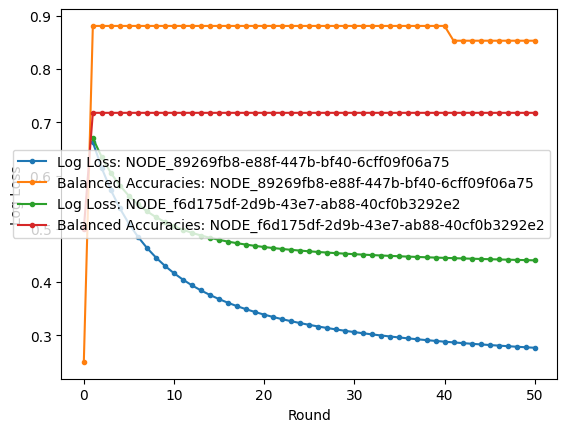

2026-02-24 10:06:49,707 fedbiomed WARNING - Node NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 is disconnected. Request/task that are created for this node will be flushed

2026-02-24 10:06:57,706 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

2026-02-24 10:06:57,707 fedbiomed INFO - Node NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 is back online!

In [53]:
# Globally normalized

# Epochs 1
# Rounds 50

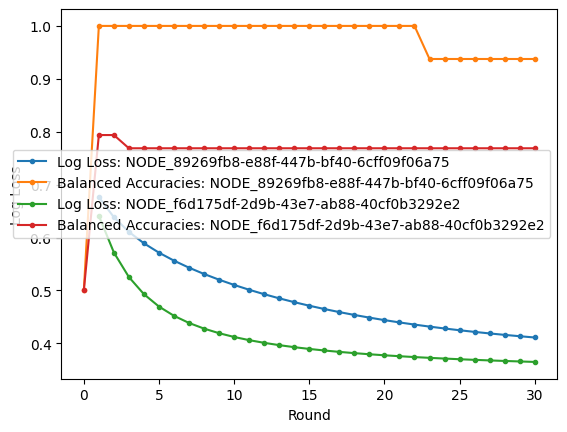

In [45]:
# Globally normalized

# Epochs 2
# Rounds 30

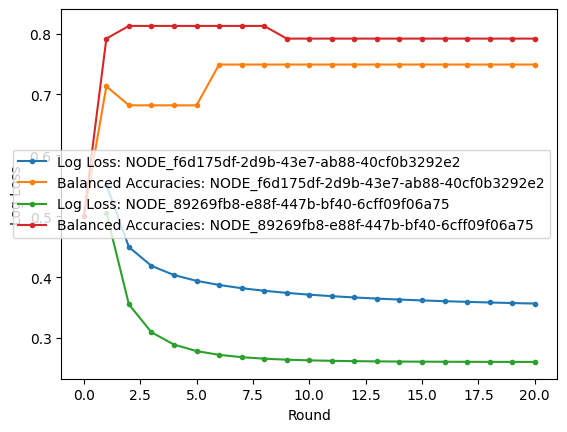

In [122]:
# Epochs 10
# Rounds 20

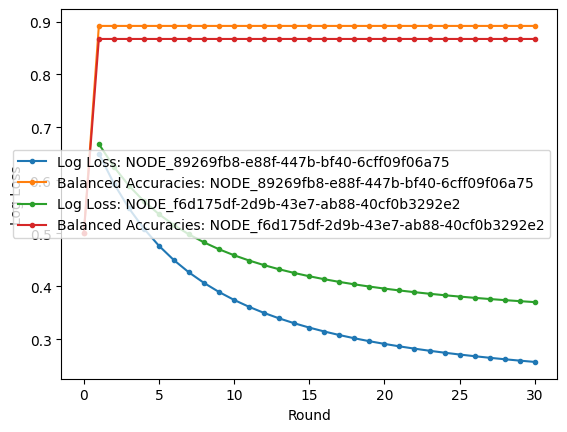

In [132]:
# Epochs 1
# Rounds 30